# Exemple d'utilisation

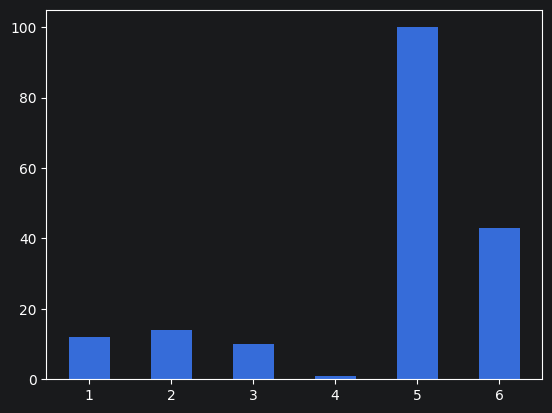

In [1]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5, 6]
y = [12, 14, 10, 1, 100, 43]
plt.bar(x, y, width=0.5)
plt.show()

## Calculer la surface d'un disque


In [2]:
import math
R = 10
math.pi*R*R


314.1592653589793

Supposons que nous souhaitions pouvoir mettre à l’échelle le graphique de notre exemple précédent. Nous aurons donc besoin d’un paramètre (« scale ») qui permettra simplement de multiplier nos éléments sur l’axe des ordonnées.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, interact_manual
from ipywidgets import widgets

@interact
def graph(scale=widgets.IntSlider(min=1, max=10, step=1, value=1)):
    x = [1, 2, 3, 4, 5, 6]
    y = [12, 14, 10, 1, 100, 43]
    y2 = scale*np.array(y)
    plt.bar(x, y2, width=0.5)

    plt.show()

interactive(children=(IntSlider(value=1, description='scale', max=10, min=1), Output()), _dom_classes=('widget…

# Exercice

Supposons que vous vouliez écrire un document dans lequel vous calculez le volume des différentes planètes du système solaire. Limitons-nous aux données suivantes :
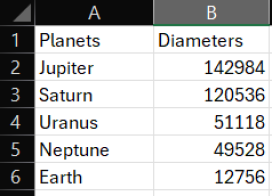


Soient les diamètres suivants :

- Jupiter : 142984
- Saturn : 120536
- Uranus : 51118
- Neptune : 49528
- Earth : 12756

La formule utilisée pour calculer le volume d'une sphère est la suivante :

$$
V = \frac{4}{3} \cdot \pi \cdot R^3
$$

Où $R$ est le rayon de la sphère.


Jupiter volume is : 1530597322872155.8 km^3
Saturn volume is : 916956953252093.4 km^3
Uranus volume is : 69939123169377.484 km^3
Neptune volume is : 63613749640082.02 km^3
Earth volume is : 1086781292542.8892 km^3


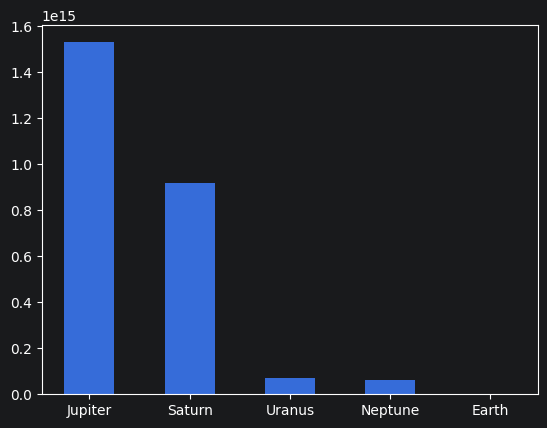

In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt


planetNames = np.array(["Jupiter", "Saturn", "Uranus", "Neptune", "Earth"])
diameters = np.array([142984, 120536, 51118, 49528, 12756])
volumes = np.array([])
index = 0
for diameter in diameters:
    vol = 4/3 * math.pi * math.pow(diameter/2,3) # volume = 4/3 * pi * R puissance 3
    print(f"{planetNames[index]} volume is : {vol} km^3" )
    volumes = np.append(volumes, vol)
    index+=1

plt.bar(planetNames, volumes, width=0.5)
plt.show()

Voici une version avec un Dropdown pour choisir la planète à agrandir, et un Slider pour régler le facteur :

In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

planet_names = np.array(["Jupiter", "Saturn", "Uranus", "Neptune", "Earth"])
diameters = np.array([142984, 120536, 51118, 49528, 12756])

volumes = 4 / 3 * math.pi * (diameters / 2) ** 3

@interact(
    planet=widgets.Dropdown(
        options=list(planet_names),
        value="Earth",
        description="Planète"
    ),
    scale=widgets.IntSlider(
        min=1,
        max=200,
        step=1,
        value=1,
        description="Facteur"
    )
)
def graph(planet, scale):
    display_volumes = volumes.copy()
    index = np.where(planet_names == planet)[0][0]
    display_volumes[index] *= scale

    plt.figure(figsize=(10, 5))
    plt.bar(planet_names, display_volumes, color=["orange", "gold", "lightblue", "blue", "green"])
    plt.title(f"Volume des planètes - {planet} x{scale}")
    plt.ylabel("Volume (km^3)")
    plt.show()

interactive(children=(Dropdown(description='Planète', index=4, options=(np.str_('Jupiter'), np.str_('Saturn'),…

Version encore plus utile : combiner ça avec une case pour passer en échelle logarithmique :

In [8]:
@interact(
    planet=widgets.Dropdown(options=list(planet_names), value="Earth", description="Planète"),
    scale=widgets.IntSlider(min=1, max=200, step=1, value=1, description="Facteur"),
    log_scale=widgets.Checkbox(value=False, description="Log")
)
def graph(planet, scale, log_scale):
    display_volumes = volumes.copy()
    index = np.where(planet_names == planet)[0][0]
    display_volumes[index] *= scale

    plt.figure(figsize=(10, 5))
    plt.bar(planet_names, display_volumes, color=["orange", "gold", "lightblue", "blue", "green"])
    plt.title(f"Volume des planètes - {planet} x{scale}")

    if log_scale:
        plt.yscale("log")

    plt.ylabel("Volume (km^3)")
    plt.show()

interactive(children=(Dropdown(description='Planète', index=4, options=(np.str_('Jupiter'), np.str_('Saturn'),…